## Iran Job Market Analysis
###  Project Overview
This project analyzes the Iranian job market by collecting thousands of job advertisements from JobVision.
The primary objective is to explore hiring trends, required technical skills, salary ranges, experience requirements, and regional demand across software engineering and data-related positions.
The analysis will also prepare the dataset for subsequent machine learning tasks and predictive modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings("ignore")

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

DATA_PATH = "../data/processed/jobs_clean.csv"


In [2]:
df = pd.read_csv(DATA_PATH)
df.head()

,keyword,job_id,title,company,province,city,salary_visible,experience_years,description,work_type,seniority,category,company_size,industries,benefits,salary_title,salary_min,salary_max,gender,required_age_min,required_age_max,military,work_days,business_trip,software,software_levels,first_activation,activation,expire,application_count,internship,remote,urgent
0,python,1396130,برنامه نویس Python,بارکس,تهران,تهران,False,5,ما برای توسعه ERP شرکت بر پایه Odoo به دنبال یک توسعه‌دهنده مسلط هستیم که توانایی توسعه ماژول‌ها...,Full Time,Senior Specialist,"IT - Software Development (Web,Moblie,…)",11 - 50 employees,Transportation / Logistics,"Loan,Bonus,Snacks\r\n,Occasional packages and gifts",NaN,NaN,NaN,Men / Women,NaN,NaN,False,شنبه تا چهارشنبه 8ت5پنج شنبه از 8صبح الی2,NaN,"Python,Oracle Database,GIT","Advanced,Basic,Basic",2026-05-20 15:30:13,2026-05-20 15:30:13,2026-07-19 15:30:13,495.0,False,False,True
1,python,1401623,Senior Backend Engineer(Python/FastAPI)- Shoraka,بیمه بازار,تهران,تهران,False,3,We are looking for a Senior Backend Engineer to join our team and contribute to the development ...,Full Time,Senior Specialist,"IT - Software Development (Web,Moblie,…)",501 - 1000 employees,"Internet Provider / E-commerce / Online Services,Insurance",NaN,NaN,NaN,NaN,Men / Women,NaN,NaN,False,Saturday to Wednesday,NaN,"Python,PostgreSql,Prometheus,Gerafana,Docker,Redis,Kubernetes","Advanced,Intermediate,Intermediate,Intermediate,Intermediate,Intermediate,Intermediate",NaN,NaN,NaN,805.0,False,True,True
2,python,1436012,برنامه نویس Python,ارتباطات فرهنگ آزما,تهران,تهران,False,2,ما در تیم تحقیق و توسعه فرهنگ آزما به دنبال یک توسعه دهنده Backend هستیم تا به تیم ما بپیوندد و ...,Full Time,Specialist,"IT - Software Development (Web,Moblie,…)",11 - 50 employees,"IT / Software / Hardware,Internet Provider / E-commerce / Online Services",Occasional packages and gifts,NaN,NaN,NaN,Men / Women,22.0,40.0,False,شنبه تا چهارشنبه 8:30 الی 18,NaN,"Python,Django,GIT,MySql,PostgreSql,Redis,Linux,Rest API,Unit Testing","Advanced,Advanced,Advanced,Intermediate,Intermediate,Basic,Intermediate,Intermediate,Basic",NaN,NaN,NaN,354.0,False,False,False
3,python,1390562,برنامه نویس بک‌اند (Python/Django),شرکت بیمۀ زندگی باران,تهران,تهران,False,3,اگر توسعه‌دهنده‌ای هستید که چالش‌های فنی شما را هیجان‌زده می‌کند و به ساخت راهکارهای خلاقانه علا...,Full Time,Specialist,"IT - Software Development (Web,Moblie,…)",11 - 50 employees,Insurance,"Loan,Bonus,Health insurance\r\n,Flexible working hours\r\n,Learning stipends\r\n,Purchasing coup...",NaN,NaN,NaN,Men / Women,23.0,33.0,True,شنبه تا سه شنبه از 08:00 الی 17:00 و چهارشنبه از ساعت 08:00 الی ساعت 16:00 (با یک ساعت شناوری صبح),NaN,"Python,Django,GIT,Linux","Intermediate,Intermediate,Basic,Basic",2026-05-25 09:28:51,2026-06-14 09:28:52,2026-07-24 09:28:51,882.0,False,False,True
4,python,1429358,برنامه نویس Python,شرکت پیشگامان توسعه ارتباطات,تهران,تهران,False,2,نکات فنی: تسلط بر Django آشنایی با DRF آشنایی با Design Patterns آشنایی با Git داشتن آشنایی و سا...,Full Time,Specialist,"IT - Software Development (Web,Moblie,…)",201 - 500 employees,"IT / Software / Hardware,Internet Provider / E-commerce / Online Services","Health insurance\r\n,Occasional packages and gifts",NaN,NaN,NaN,Men / Women,19.0,40.0,True,شنبه تا سه‌شنبه 8 تا 17، چهارشنبه 8 تا 16,NaN,"Linux,Django,GIT,Python","Intermediate,Advanced,Intermediate,Intermediate",NaN,NaN,NaN,587.0,False,False,False


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12255 entries, 0 to 12254
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   keyword            12255 non-null  str    
 1   job_id             12255 non-null  int64  
 2   title              12255 non-null  str    
 3   company            12255 non-null  str    
 4   province           12231 non-null  str    
 5   city               12255 non-null  str    
 6   salary_visible     12255 non-null  bool   
 7   experience_years   12255 non-null  int64  
 8   description        12255 non-null  str    
 9   work_type          12255 non-null  str    
 10  seniority          12255 non-null  str    
 11  category           12255 non-null  str    
 12  company_size       12255 non-null  str    
 13  industries         12255 non-null  str    
 14  benefits           9899 non-null   str    
 15  salary_title       4165 non-null   str    
 16  salary_min         4165 non-null 

In [4]:
overview = pd.DataFrame({
    "Metric": [
        "Total Job Posts",
        "Unique Companies",
        "Unique Provinces",
        "Unique Cities",
        "Unique Job Titles"
    ],
    "Value": [
        len(df),
        df["company"].nunique(),
        df["province"].nunique(),
        df["city"].nunique(),
        df["title"].nunique()
    ]
})

overview

,Metric,Value
0,Total Job Posts,12255
1,Unique Companies,5938
2,Unique Provinces,31
3,Unique Cities,258
4,Unique Job Titles,6687


In [5]:
missing = (df.isna().sum().to_frame("Missing"))
missing["Percentage"] = (missing["Missing"] / len(df) * 100).round(2)
missing = (missing.query("Missing > 0").sort_values("Percentage", ascending=False))
missing

,Missing,Percentage
business_trip,11230,91.64
salary_min,8090,66.01
salary_max,8090,66.01
salary_title,8090,66.01
required_age_min,4112,33.55
required_age_max,4008,32.71
software,3595,29.33
software_levels,3595,29.33
first_activation,3514,28.67
activation,3514,28.67


In [6]:
print(f"Memory Usage (MB): {df.memory_usage(deep=True).sum() / 1024 ** 2:.2f}")

Memory Usage (MB): 46.42


# 1. Hiring Demand Analysis
This section explores the hiring demand across different job positions to identify the most frequently advertised roles in the Iranian technology job market.

## 1.1 Job Titles

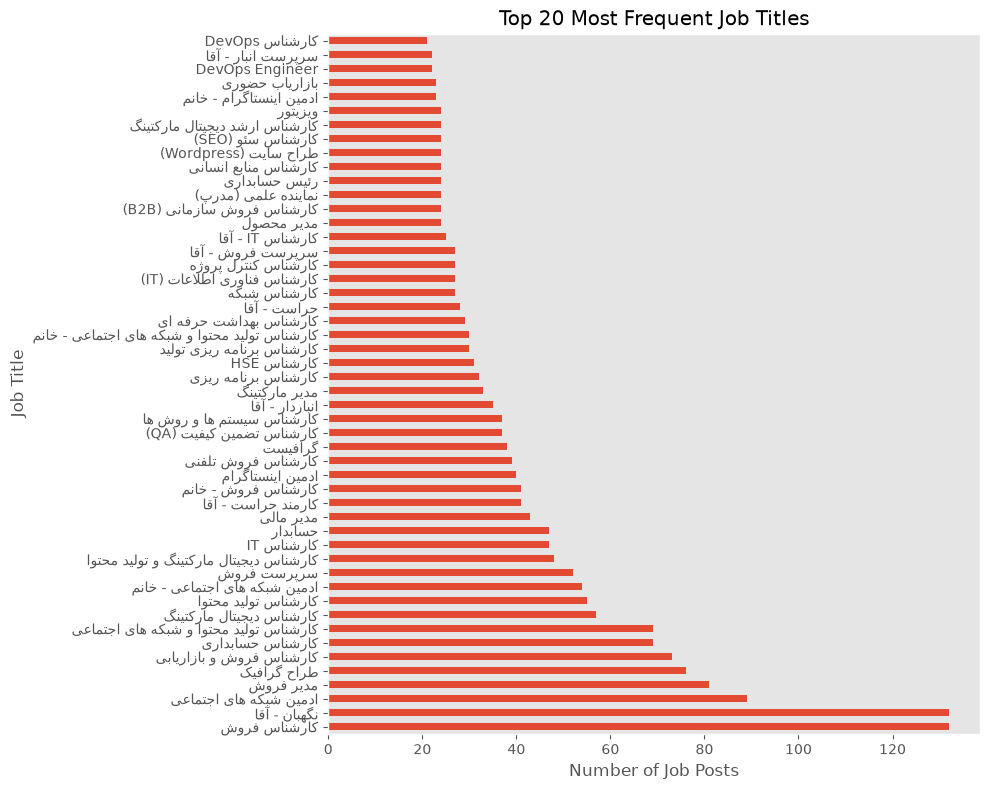

In [7]:
title_counts = df["title"].value_counts()[:50]
title_counts.head(50).plot(kind="barh", figsize=(10,8))
plt.title("Top 20 Most Frequent Job Titles"); plt.grid()
plt.xlabel("Number of Job Posts"); plt.ylabel("Job Title")
plt.tight_layout(); plt.show()

In [8]:
# How concentrated is the job market?
title_distribution = (df["title"].value_counts(normalize=True).mul(100))
top10_share = title_distribution.head(10).sum()
top20_share = title_distribution.head(20).sum()
top50_share = title_distribution.head(50).sum()
print(f"Top 10 titles account for {top10_share:.2f}% of all job postings")
print(f"Top 20 titles account for {top20_share:.2f}% of all job postings")
print(f"Top 50 titles account for {top50_share:.2f}% of all job postings")

Top 10 titles account for 6.80% of all job postings
Top 20 titles account for 10.49% of all job postings
Top 50 titles account for 17.18% of all job postings


## 1.2 Job Categories
Individual job titles can vary significantly across companies, making direct comparisons difficult.
To obtain a broader view of the labor market, this section analyzes standardized job categories. This helps identify which professional domains receive the highest hiring demand.

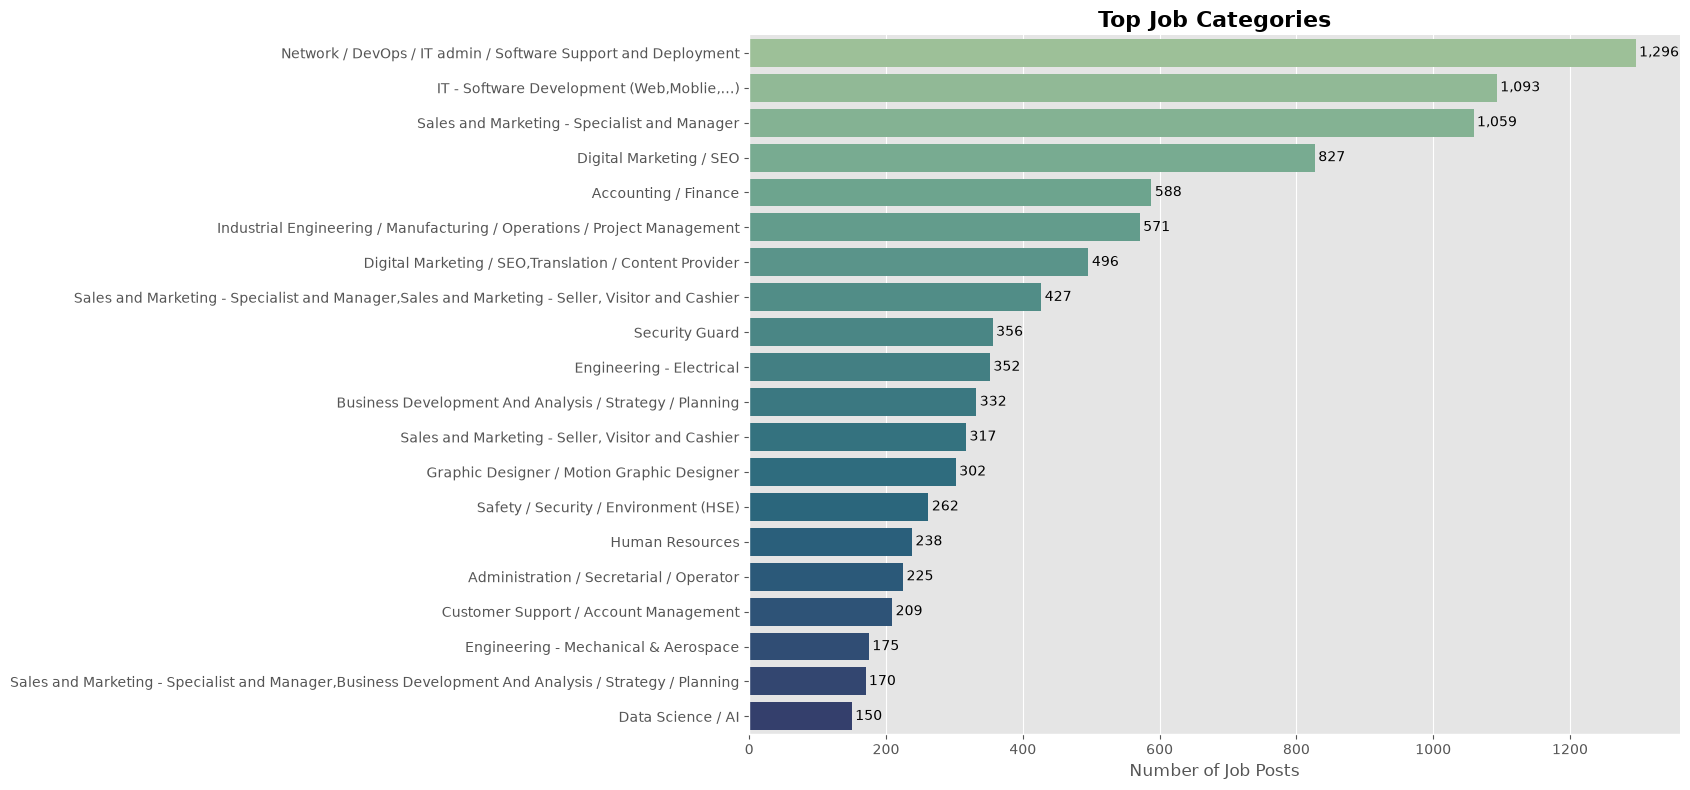

In [9]:
category_counts = (df["category"].fillna("Unknown").value_counts())
plt.figure(figsize=(17, 8))
ax = sns.barplot(x=category_counts[:20].values, y=category_counts[:20].index, hue=category_counts[:20].index, legend=False, palette="crest")
plt.title("Top Job Categories", fontsize=16, weight="bold")
plt.xlabel("Number of Job Posts")
plt.ylabel("")
for i, value in enumerate(category_counts.head(20).values):
    ax.text(value + 5, i, f"{value:,}", va="center")
sns.despine()
plt.tight_layout(); plt.show()

In [10]:
category_share = (df["category"].fillna("Unknown").value_counts(normalize=True).mul(100))
print(f"Top 5 categories represent" f"{category_share.head(5).sum():.2f}% of all jobs.")
print(f"Top 10 categories represent" f"{category_share.head(10).sum():.2f}% of all jobs.")

Top 5 categories represent39.68% of all jobs.
Top 10 categories represent57.65% of all jobs.


## 1.3 Industry Analysis

This section explores the distribution of job postings across different industries to identify which sectors contribute the most to hiring activity.

In [11]:
df["industries"].head()

0                                                   Transportation / Logistics
1                   Internet Provider / E-commerce / Online Services,Insurance
2    IT / Software / Hardware,Internet Provider / E-commerce / Online Services
3                                                                    Insurance
4    IT / Software / Hardware,Internet Provider / E-commerce / Online Services
Name: industries, dtype: str

In [12]:
industry = (df["industries"].fillna("Unknown").str.split(",").explode().str.strip())
industry.head()

0                          Transportation / Logistics
1    Internet Provider / E-commerce / Online Services
1                                           Insurance
2                            IT / Software / Hardware
2    Internet Provider / E-commerce / Online Services
Name: industries, dtype: str

In [13]:
industry_counts = (industry.value_counts())
industry_counts[:20]

industries
Manufacturing & Production                               2757
IT / Software / Hardware                                 2697
Internet Provider / E-commerce / Online Services         1790
Trading / International Affairs                          1329
Consumer Goods / FMCG                                     981
Engineering Services / Technical Services & Solutions     949
Retail / Shopping center / Store                          775
Finance / Investment                                      654
Automotive                                                617
Oil & Gas / Petrochemical                                 483
Pharmaceutical                                            455
Education / Research                                      434
Construction / Building Materials & Equipment             434
Consumer Electonics / Home Appliances                     434
Banking                                                   413
Marketing / Advertising                                   4

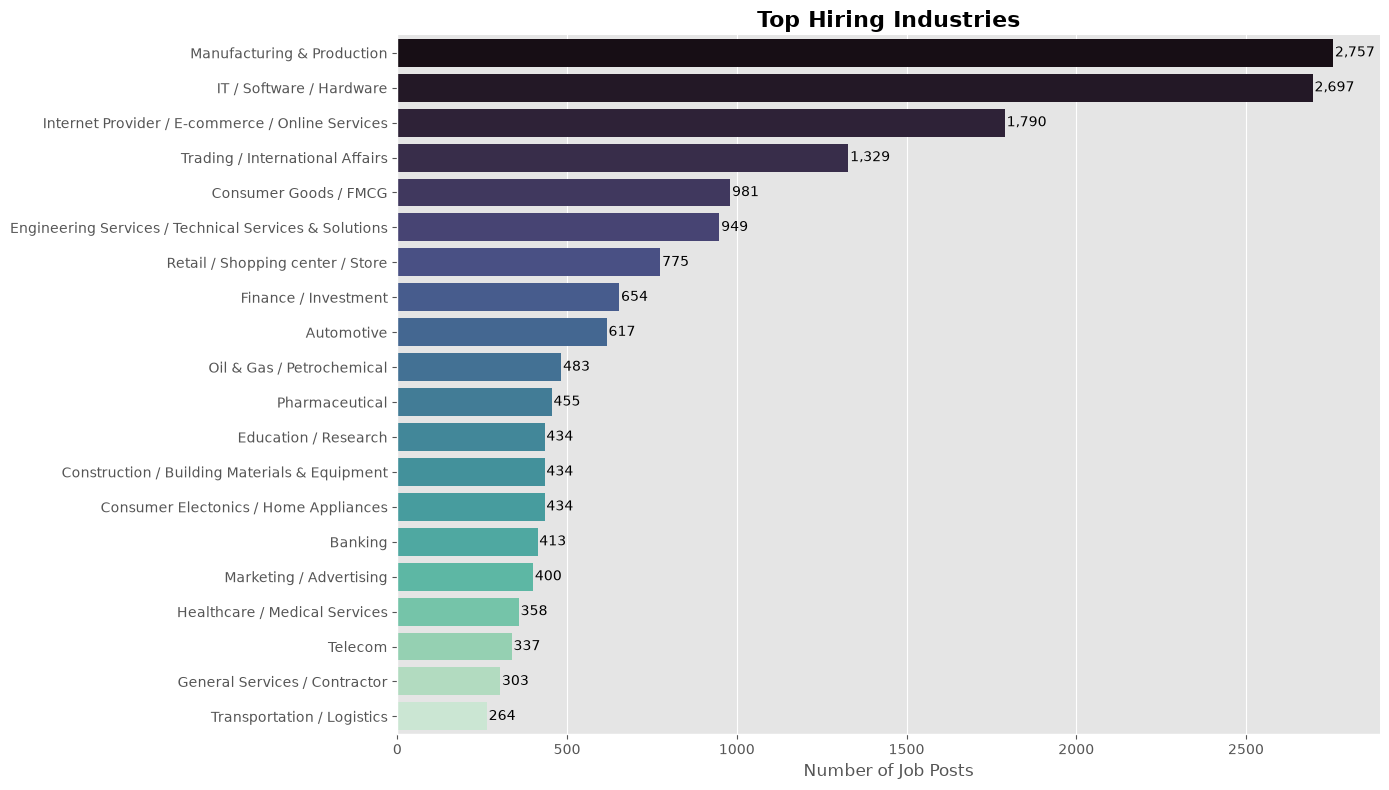

In [14]:
plt.figure(figsize=(14,8))
ax = sns.barplot(x=industry_counts[:20].values, y=industry_counts[:20].index, hue=industry_counts[:20].index, legend=False, palette="mako")
plt.title("Top Hiring Industries", fontsize=16, weight="bold")
plt.xlabel("Number of Job Posts")
plt.ylabel("")
for i, value in enumerate(industry_counts[:20].values):
    ax.text(value + 5, i, f"{value:,}", va="center")
sns.despine(); plt.tight_layout(); plt.show()

In [15]:
industry_share = (industry.value_counts(normalize=True).mul(100).round(2))
industry_share[:15]

industries
Manufacturing & Production                               13.94
IT / Software / Hardware                                 13.64
Internet Provider / E-commerce / Online Services          9.05
Trading / International Affairs                           6.72
Consumer Goods / FMCG                                     4.96
Engineering Services / Technical Services & Solutions     4.80
Retail / Shopping center / Store                          3.92
Finance / Investment                                      3.31
Automotive                                                3.12
Oil & Gas / Petrochemical                                 2.44
Pharmaceutical                                            2.30
Education / Research                                      2.19
Construction / Building Materials & Equipment             2.19
Consumer Electonics / Home Appliances                     2.19
Banking                                                   2.09
Name: proportion, dtype: float64

In [16]:
print(f"Top 5 industries account for {industry_share.head(5).sum():.2f}% of all industry mentions.")
print(f"Top 10 industries account for {industry_share.head(10).sum():.2f}% of all industry mentions.")

Top 5 industries account for 48.31% of all industry mentions.
Top 10 industries account for 65.90% of all industry mentions.


## 2. Work Type Analysis
Employment type is one of the most important characteristics of a job market.
This analysis examines the distribution of work arrangements to understand whether employers primarily seek full-time employees or offer more flexible work options such as part-time, project-based, contract, or internship positions.

In [17]:
df["work_type"].value_counts(dropna=False)

work_type
Full Time                 10741
Full Time Or Part Time      697
Part Time                   433
Project - based             384
Name: count, dtype: int64

## Market Structure

In [24]:
300 + 278 + 200

778

In [25]:
300 + 90 + 128

518

In [26]:
778 - 518

260